# Week 10 Homework — ARIA v7.0: The All-Weather Auditor

**Course:** NTU Remote Sensing & Spatial Information Analysis  
**Case study:** 花蓮馬太鞍溪流域 — 2025 鳳凰颱風後淹水與堰塞湖偵測  
**Notebook:** `Week10_ARIA_v70_PoWeiHuang.ipynb`

本 notebook 完成四個核心任務：

1. **Task 1:** Sentinel-1 RTC SAR all-weather flood detection  
2. **Task 2:** Sentinel-2 NDWI × Sentinel-1 SAR sensor fusion confidence map  
3. **Task 3:** Copernicus DEM slope-based topographic audit  
4. **Task 4:** AI strategic briefing and ARIA v7.0 comparison report  

> Captain's Log: 本週的核心問題是「颱風期間雲遮嚴重時，如何仍然提供可操作的淹水判釋」。因此本 notebook 以 SAR 作為 all-weather 主體，並用 optical NDWI 與 DEM 作為交叉驗證與錯誤審計。

## 0. Environment Setup

Captain's Log: 這一段先集中管理參數，避免 BBOX、日期、閾值散落在不同 code cell。`.env` 不應該上傳到 GitHub，但可以作為本地重現分析的設定來源。

In [1]:
import os
import time
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

from scipy import ndimage
from scipy.ndimage import median_filter, zoom

import pystac_client
import planetary_computer as pc
import stackstac

try:
    from dotenv import load_dotenv
    load_dotenv()
except Exception:
    # If python-dotenv is not installed, the code below can still use default values.
    pass

warnings.filterwarnings("ignore", category=RuntimeWarning)

OUTPUT_DIR = Path("outputs_week10")
OUTPUT_DIR.mkdir(exist_ok=True)

In [2]:
def getenv_float(name, default):
    """Read a float value from environment variables."""
    return float(os.getenv(name, default))

def getenv_int(name, default):
    """Read an integer value from environment variables."""
    return int(os.getenv(name, default))

def getenv_str(name, default):
    """Read a string value from environment variables."""
    return os.getenv(name, default)

def getenv_int_list(name, default_csv):
    """Read comma-separated integers from environment variables."""
    raw = os.getenv(name, default_csv)
    return [int(x.strip()) for x in raw.split(",") if x.strip()]

# Study area
HUALIEN_BBOX = [
    getenv_float("BBOX_WEST", 121.2574),
    getenv_float("BBOX_SOUTH", 23.6546),
    getenv_float("BBOX_EAST", 121.4984),
    getenv_float("BBOX_NORTH", 23.7447),
]

# Time ranges
PRE_DATE_RANGE = getenv_str("PRE_DATE_RANGE", "2025-10-01/2025-11-05")
POST_DATE_RANGE = getenv_str("POST_DATE_RANGE", "2025-11-12/2025-11-30")

# Collections and projection
STAC_ENDPOINT = getenv_str("STAC_ENDPOINT", "https://planetarycomputer.microsoft.com/api/stac/v1")
S1_COLLECTION = getenv_str("S1_COLLECTION", "sentinel-1-rtc")
S2_COLLECTION = getenv_str("S2_COLLECTION", "sentinel-2-l2a")
DEM_COLLECTION = getenv_str("DEM_COLLECTION", "cop-dem-glo-30")
TARGET_EPSG = getenv_int("TARGET_EPSG", 32651)

# Thresholds and cleaning parameters
SAR_THRESHOLD = getenv_float("SAR_THRESHOLD", -18.0)
NDWI_THRESHOLD = getenv_float("NDWI_THRESHOLD", 0.0)  # muddy flood water often needs lower threshold
SLOPE_THRESHOLD = getenv_float("SLOPE_THRESHOLD", 25.0)
MIN_WATER_PIXELS = getenv_int("MIN_WATER_PIXELS", 50)
MEDIAN_FILTER_SIZE = getenv_int("MEDIAN_FILTER_SIZE", 5)
MORPH_OPENING_SIZE = getenv_int("MORPH_OPENING_SIZE", 3)

# SCL classes: 2 dark area, 4 vegetation, 5 bare soil, 6 water, 7 unclassified, 11 snow/ice
CLEAR_SCL_CLASSES = getenv_int_list("CLEAR_SCL_CLASSES", "2,4,5,6,7,11")

PIXEL_SIZE_M = getenv_float("PIXEL_SIZE_M", 10.0)
PIXEL_AREA_KM2 = (PIXEL_SIZE_M ** 2) / 1_000_000

params = {
    "HUALIEN_BBOX": HUALIEN_BBOX,
    "PRE_DATE_RANGE": PRE_DATE_RANGE,
    "POST_DATE_RANGE": POST_DATE_RANGE,
    "TARGET_EPSG": TARGET_EPSG,
    "SAR_THRESHOLD": SAR_THRESHOLD,
    "NDWI_THRESHOLD": NDWI_THRESHOLD,
    "SLOPE_THRESHOLD": SLOPE_THRESHOLD,
    "MIN_WATER_PIXELS": MIN_WATER_PIXELS,
    "MEDIAN_FILTER_SIZE": MEDIAN_FILTER_SIZE,
    "MORPH_OPENING_SIZE": MORPH_OPENING_SIZE,
    "CLEAR_SCL_CLASSES": CLEAR_SCL_CLASSES,
}
pd.Series(params, name="value")

HUALIEN_BBOX          [121.2574, 23.6546, 121.4984, 23.7447]
PRE_DATE_RANGE                         2025-10-01/2025-11-05
POST_DATE_RANGE                        2025-11-12/2025-11-30
TARGET_EPSG                                            32651
SAR_THRESHOLD                                          -18.0
NDWI_THRESHOLD                                           0.0
SLOPE_THRESHOLD                                         25.0
MIN_WATER_PIXELS                                          50
MEDIAN_FILTER_SIZE                                         5
MORPH_OPENING_SIZE                                         3
CLEAR_SCL_CLASSES                        [2, 4, 5, 6, 7, 11]
Name: value, dtype: object

In [3]:
# Open Planetary Computer STAC catalog.
catalog = pystac_client.Client.open(
    STAC_ENDPOINT,
    modifier=pc.sign_inplace,
)
catalog

<Client id=microsoft-pc>

## 1. Utility Functions

Captain's Log: 這些函式負責 STAC item 摘要、影像串流、shape 對齊、morphological cleanup 與面積統計。把共用邏輯寫成函式，可以降低後面 Task 1–3 的重複與錯誤。

In [4]:
def item_datetime(item):
    """Return item datetime as pandas Timestamp."""
    if item.datetime is not None:
        return pd.Timestamp(item.datetime)
    dt = item.properties.get("datetime")
    return pd.Timestamp(dt) if dt else pd.NaT

def get_orbit_state(item):
    """Extract SAR orbit direction from a STAC item."""
    props = item.properties
    return (
        props.get("sat:orbit_state")
        or props.get("sar:orbit_state")
        or props.get("orbitDirection")
        or props.get("s1:orbit_state")
        or "unknown"
    )

def get_relative_orbit(item):
    """Extract relative orbit number when available."""
    props = item.properties
    return (
        props.get("sat:relative_orbit")
        or props.get("sat:relative_orbit_number")
        or props.get("relativeOrbitNumber")
        or props.get("s1:relative_orbit")
        or "unknown"
    )

def summarize_items(items, sensor="S1"):
    """Summarize STAC items into a readable table."""
    rows = []
    for i, item in enumerate(items):
        props = item.properties
        row = {
            "idx": i,
            "id": item.id,
            "datetime": item_datetime(item),
            "collection": item.collection_id,
        }
        if sensor.upper() == "S1":
            row.update({
                "orbit_state": get_orbit_state(item),
                "relative_orbit": get_relative_orbit(item),
                "platform": props.get("platform", "unknown"),
            })
        if sensor.upper() == "S2":
            row.update({
                "cloud_cover": props.get("eo:cloud_cover", np.nan),
                "platform": props.get("platform", "unknown"),
            })
        rows.append(row)
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values("datetime").reset_index(drop=True)

def search_items(collection, bbox, datetime_range=None, max_items=100):
    """Search Planetary Computer STAC items for a collection, bbox, and optional datetime range."""
    kwargs = {
        "collections": [collection],
        "bbox": bbox,
        "max_items": max_items,
    }
    if datetime_range is not None:
        kwargs["datetime"] = datetime_range
    search = catalog.search(**kwargs)
    return list(search.items())

def safe_compute(x, retries=3, sleep_seconds=5):
    """Compute a Dask/xarray object with simple retry handling for signed COG reads."""
    last_error = None
    for attempt in range(1, retries + 1):
        try:
            return x.compute()
        except Exception as exc:
            last_error = exc
            print(f"Compute failed on attempt {attempt}/{retries}: {exc}")
            if attempt < retries:
                time.sleep(sleep_seconds)
    raise last_error

def dataarray_to_2d(da):
    """Squeeze a stackstac DataArray to a 2-D y-x array."""
    out = da.squeeze(drop=True)
    while out.ndim > 2:
        out = out.isel({out.dims[0]: 0})
    return out

def align_to_shape(arr, target_shape, order=0, fill_value=np.nan):
    """Resize a 2-D array to target_shape using zoom, then crop/pad if needed."""
    arr = np.asarray(arr)
    if arr.shape == target_shape:
        return arr

    factors = (target_shape[0] / arr.shape[0], target_shape[1] / arr.shape[1])
    resized = zoom(arr, factors, order=order)

    # Crop if too large
    resized = resized[:target_shape[0], :target_shape[1]]

    # Pad if too small
    pad_y = max(0, target_shape[0] - resized.shape[0])
    pad_x = max(0, target_shape[1] - resized.shape[1])
    if pad_y or pad_x:
        resized = np.pad(
            resized,
            ((0, pad_y), (0, pad_x)),
            mode="constant",
            constant_values=fill_value,
        )

    return resized

def clean_binary_mask(mask, min_pixels=50, opening_size=3):
    """Apply opening, closing, and connected component filtering to a binary mask."""
    mask = np.asarray(mask).astype(bool)
    structure = np.ones((opening_size, opening_size), dtype=bool)

    opened = ndimage.binary_opening(mask, structure=structure)
    closed = ndimage.binary_closing(opened, structure=structure)

    labels, n_labels = ndimage.label(closed)
    if n_labels == 0:
        return closed, labels, pd.DataFrame(columns=["component", "pixel_count", "area_km2"])

    counts = np.bincount(labels.ravel())
    keep = counts >= min_pixels
    keep[0] = False  # background
    cleaned = keep[labels]

    comp_rows = []
    for comp_id, count in enumerate(counts):
        if comp_id == 0:
            continue
        comp_rows.append({
            "component": comp_id,
            "pixel_count": int(count),
            "area_km2": count * PIXEL_AREA_KM2,
            "kept": bool(keep[comp_id]),
        })
    comp_table = pd.DataFrame(comp_rows).sort_values("pixel_count", ascending=False)

    return cleaned, labels, comp_table

def area_from_mask(mask, pixel_area_km2=PIXEL_AREA_KM2):
    """Calculate area in square kilometers from a boolean mask."""
    return float(np.nansum(mask.astype(bool)) * pixel_area_km2)

def print_sanity_check(mask, label, max_fraction=0.50):
    """Print sanity-check warnings for unrealistic water/flood masks."""
    detected_fraction = np.nansum(mask) / mask.size
    print(f"{label}: detected fraction = {detected_fraction:.2%}")
    if detected_fraction > max_fraction:
        print("⚠️ Warning: detected area is very large. Check threshold, median filter, morphology, and terrain effects.")
    elif detected_fraction == 0:
        print("⚠️ Warning: no detection. Check threshold and input data availability.")
    else:
        print("✅ Detection fraction is within a plausible first-pass range.")

In [5]:
def plot_sar_task(raw_db, filtered_db, flood_mask, threshold, title_prefix="Post-event SAR"):
    """Create the required 2×2 SAR detection figure."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))

    im0 = axes[0, 0].imshow(raw_db, cmap="gray")
    axes[0, 0].set_title("(a) Raw SAR VV backscatter (dB)")
    plt.colorbar(im0, ax=axes[0, 0], fraction=0.046)

    im1 = axes[0, 1].imshow(filtered_db, cmap="gray")
    axes[0, 1].set_title(f"(b) Median filtered SAR, size={MEDIAN_FILTER_SIZE}")
    plt.colorbar(im1, ax=axes[0, 1], fraction=0.046)

    im2 = axes[1, 0].imshow(flood_mask, cmap="Blues", vmin=0, vmax=1)
    axes[1, 0].set_title(f"(c) Binary flood mask, threshold={threshold} dB")
    plt.colorbar(im2, ax=axes[1, 0], fraction=0.046)

    axes[1, 1].imshow(filtered_db, cmap="gray")
    axes[1, 1].imshow(np.ma.masked_where(~flood_mask, flood_mask), cmap="Blues", alpha=0.55, vmin=0, vmax=1)
    axes[1, 1].set_title("(d) Flood overlay on filtered SAR")

    for ax in axes.ravel():
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(title_prefix, fontsize=16)
    fig.tight_layout()
    out = OUTPUT_DIR / "task1_sar_2x2_detection.png"
    fig.savefig(out, dpi=180, bbox_inches="tight")
    print(f"Saved: {out}")
    plt.show()

def plot_histogram(filtered_db, threshold):
    """Plot SAR VV histogram and threshold line."""
    valid = filtered_db[np.isfinite(filtered_db)]
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(valid.ravel(), bins=100)
    ax.axvline(threshold, linestyle="--", linewidth=2, label=f"Threshold = {threshold} dB")
    ax.set_title("Filtered SAR VV Backscatter Histogram")
    ax.set_xlabel("VV backscatter (dB)")
    ax.set_ylabel("Pixel count")
    ax.legend()
    out = OUTPUT_DIR / "task1_sar_histogram_threshold.png"
    fig.savefig(out, dpi=180, bbox_inches="tight")
    print(f"Saved: {out}")
    plt.show()

def plot_fusion_map(fusion, title, filename):
    """Plot 4-class confidence map with legend."""
    # 0 no detection, 1 optical only, 2 SAR only, 3 high confidence
    colors = ["#f2f2f2", "#fdae61", "#abd9e9", "#1a9850"]
    labels = {
        0: "No Detection",
        1: "Optical Only — manual review",
        2: "SAR Only — cloudy/review",
        3: "High Confidence — SAR + optical",
    }
    cmap = ListedColormap(colors)
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

    fig, ax = plt.subplots(figsize=(9, 8))
    ax.imshow(fusion, cmap=cmap, norm=norm)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

    handles = [Patch(facecolor=colors[k], edgecolor="black", label=labels[k]) for k in range(4)]
    ax.legend(handles=handles, loc="lower right", frameon=True)
    out = OUTPUT_DIR / filename
    fig.savefig(out, dpi=180, bbox_inches="tight")
    print(f"Saved: {out}")
    plt.show()

def class_area_table(fusion, pixel_area_km2=PIXEL_AREA_KM2):
    """Calculate area by confidence class."""
    labels = {
        0: "No Detection",
        1: "Optical Only",
        2: "SAR Only / Cloudy or Review",
        3: "High Confidence",
    }
    rows = []
    total_pixels = fusion.size
    for cls, label in labels.items():
        pixels = int(np.sum(fusion == cls))
        rows.append({
            "class": cls,
            "classification": label,
            "pixels": pixels,
            "area_km2": pixels * pixel_area_km2,
            "percent_of_aoi": pixels / total_pixels * 100,
        })
    return pd.DataFrame(rows)

## Task 1 — SAR All-Weather Flood Detection

Captain's Log: SAR 的物理邏輯是水面會造成鏡面反射，使雷達回波偏低，因此在 VV dB 影像中通常呈現暗色。為避免 raw SAR speckle 造成破碎誤判，本段先做 median filter，再用閾值與形態學清理萃取 flood mask。

In [6]:
# Search Sentinel-1 RTC items before and after the event.
s1_pre_items = search_items(S1_COLLECTION, HUALIEN_BBOX, PRE_DATE_RANGE)
s1_post_items = search_items(S1_COLLECTION, HUALIEN_BBOX, POST_DATE_RANGE)

s1_pre_table = summarize_items(s1_pre_items, sensor="S1")
s1_post_table = summarize_items(s1_post_items, sensor="S1")

print("Pre-event Sentinel-1 RTC items:")
display(s1_pre_table)

print("Post-event Sentinel-1 RTC items:")
display(s1_post_table)

Pre-event Sentinel-1 RTC items:


,idx,id,datetime,collection,orbit_state,relative_orbit,platform
0,10,S1A_IW_GRDH_1SDV_20251002T215251_20251002T2153...,2025-10-02 21:53:03.631098+00:00,sentinel-1-rtc,descending,105,sentinel-1a
1,9,S1C_IW_GRDH_1SDV_20251008T215151_20251008T2152...,2025-10-08 21:52:04.090349+00:00,sentinel-1-rtc,descending,105,sentinel-1c
2,8,S1A_IW_GRDH_1SDV_20251012T100124_20251012T1001...,2025-10-12 10:01:36.891549+00:00,sentinel-1-rtc,ascending,69,sentinel-1a
3,7,S1A_IW_GRDH_1SDV_20251014T215251_20251014T2153...,2025-10-14 21:53:03.914763+00:00,sentinel-1-rtc,descending,105,sentinel-1a
4,6,S1C_IW_GRDH_1SDV_20251018T100018_20251018T1000...,2025-10-18 10:00:31.062237+00:00,sentinel-1-rtc,ascending,69,sentinel-1c
5,5,S1C_IW_GRDH_1SDV_20251020T215151_20251020T2152...,2025-10-20 21:52:03.889372+00:00,sentinel-1-rtc,descending,105,sentinel-1c
6,4,S1A_IW_GRDH_1SDV_20251024T100123_20251024T1001...,2025-10-24 10:01:36.374987+00:00,sentinel-1-rtc,ascending,69,sentinel-1a
7,3,S1A_IW_GRDH_1SDV_20251026T215251_20251026T2153...,2025-10-26 21:53:03.718435+00:00,sentinel-1-rtc,descending,105,sentinel-1a
8,2,S1C_IW_GRDH_1SDV_20251030T100018_20251030T1000...,2025-10-30 10:00:30.708803+00:00,sentinel-1-rtc,ascending,69,sentinel-1c
9,1,S1C_IW_GRDH_1SDV_20251101T215151_20251101T2152...,2025-11-01 21:52:03.680039+00:00,sentinel-1-rtc,descending,105,sentinel-1c


Post-event Sentinel-1 RTC items:


,idx,id,datetime,collection,orbit_state,relative_orbit,platform
0,4,S1C_IW_GRDH_1SDV_20251113T215150_20251113T2152...,2025-11-13 21:52:02.893246+00:00,sentinel-1-rtc,descending,105,sentinel-1c
1,3,S1A_IW_GRDH_1SDV_20251119T215250_20251119T2153...,2025-11-19 21:53:02.884675+00:00,sentinel-1-rtc,descending,105,sentinel-1a
2,2,S1C_IW_GRDH_1SDV_20251123T100017_20251123T1000...,2025-11-23 10:00:29.820780+00:00,sentinel-1-rtc,ascending,69,sentinel-1c
3,1,S1C_IW_GRDH_1SDV_20251125T215150_20251125T2152...,2025-11-25 21:52:02.535345+00:00,sentinel-1-rtc,descending,105,sentinel-1c
4,0,S1A_IW_GRDH_1SDV_20251129T100121_20251129T1001...,2025-11-29 10:01:34.337886+00:00,sentinel-1-rtc,ascending,69,sentinel-1a


In [7]:
def pick_s1_pre_post_pair(pre_items, post_items, preferred_orbit=None):
    """Pick pre/post Sentinel-1 RTC items with the same orbit direction."""
    if not pre_items or not post_items:
        raise ValueError("No Sentinel-1 items found. Expand date range or check BBOX/network.")

    pre_by_orbit = {}
    post_by_orbit = {}
    for item in pre_items:
        pre_by_orbit.setdefault(get_orbit_state(item), []).append(item)
    for item in post_items:
        post_by_orbit.setdefault(get_orbit_state(item), []).append(item)

    common_orbits = sorted(set(pre_by_orbit) & set(post_by_orbit))
    if not common_orbits:
        raise ValueError(
            "No common orbit direction between pre/post Sentinel-1 scenes. "
            "Expand search window or inspect orbit metadata."
        )

    if preferred_orbit and preferred_orbit in common_orbits:
        orbit = preferred_orbit
    else:
        orbit = common_orbits[0]

    pre_candidates = sorted(pre_by_orbit[orbit], key=item_datetime)
    post_candidates = sorted(post_by_orbit[orbit], key=item_datetime)

    # Latest pre-event and earliest post-event are usually the most defensible pair.
    pre_item = pre_candidates[-1]
    post_item = post_candidates[0]
    return pre_item, post_item, orbit, common_orbits

PREFERRED_ORBIT = os.getenv("PREFERRED_ORBIT", "").strip().lower() or None
pre_s1_item, post_s1_item, selected_orbit, common_orbits = pick_s1_pre_post_pair(
    s1_pre_items,
    s1_post_items,
    preferred_orbit=PREFERRED_ORBIT,
)

print(f"Common orbit directions: {common_orbits}")
print(f"Selected orbit direction: {selected_orbit}")
print(f"Selected pre-event item:  {pre_s1_item.id} | {item_datetime(pre_s1_item)}")
print(f"Selected post-event item: {post_s1_item.id} | {item_datetime(post_s1_item)}")

Common orbit directions: ['ascending', 'descending']
Selected orbit direction: ascending
Selected pre-event item:  S1A_IW_GRDH_1SDV_20251105T100123_20251105T100148_061741_07B75F_rtc | 2025-11-05 10:01:36.067979+00:00
Selected post-event item: S1C_IW_GRDH_1SDV_20251123T100017_20251123T100042_005140_00A313_rtc | 2025-11-23 10:00:29.820780+00:00


In [8]:
def load_s1_vv_db(item, bbox, epsg=32651, resolution=10):
    """Load Sentinel-1 RTC VV as dB from a signed STAC item."""
    signed_item = pc.sign(item)
    cube = stackstac.stack(
        [signed_item],
        assets=["vv"],
        epsg=epsg,
        resolution=resolution,
        bounds_latlon=bbox,
        chunksize=2048,
    )
    da = dataarray_to_2d(cube)
    vv_linear = safe_compute(da).values.astype(np.float32)
    vv_linear = np.where(vv_linear <= 0, np.nan, vv_linear)
    vv_db = 10 * np.log10(vv_linear)
    return vv_db

# Load post-event SAR for flood extraction.
post_vv_db_raw = load_s1_vv_db(post_s1_item, HUALIEN_BBOX, TARGET_EPSG, resolution=PIXEL_SIZE_M)

print("Post-event SAR array shape:", post_vv_db_raw.shape)
print("Raw VV dB range:", np.nanpercentile(post_vv_db_raw, [1, 5, 50, 95, 99]))

Post-event SAR array shape: (1026, 2470)
Raw VV dB range: [-20.45674046 -15.28576179  -8.0132494   -3.12558261  -0.22579996]


In [9]:
# Speckle filtering BEFORE thresholding.
post_vv_db_filtered = median_filter(post_vv_db_raw, size=MEDIAN_FILTER_SIZE)

# Threshold: water-like dark pixels.
sar_candidate_mask = post_vv_db_filtered < SAR_THRESHOLD

# Morphological cleanup and connected component filtering.
sar_flood_mask, sar_labels, component_table = clean_binary_mask(
    sar_candidate_mask,
    min_pixels=MIN_WATER_PIXELS,
    opening_size=MORPH_OPENING_SIZE,
)

print_sanity_check(sar_flood_mask, "SAR flood mask")

display(component_table.head(10))

sar_area_km2 = area_from_mask(sar_flood_mask)
sar_water_pixels = int(np.sum(sar_flood_mask))
sar_mean_backscatter = float(np.nanmean(post_vv_db_filtered[sar_flood_mask])) if sar_water_pixels else np.nan

task1_stats = pd.DataFrame([{
    "SAR threshold dB": SAR_THRESHOLD,
    "water pixels": sar_water_pixels,
    "flooded area km2": sar_area_km2,
    "mean backscatter in flood zone dB": sar_mean_backscatter,
    "median filter size": MEDIAN_FILTER_SIZE,
    "minimum component pixels": MIN_WATER_PIXELS,
}])

display(task1_stats)

SAR flood mask: detected fraction = 1.30%
✅ Detection fraction is within a plausible first-pass range.


,component,pixel_count,area_km2,kept
85,86,2087,0.2087,True
127,128,2013,0.2013,True
6,7,1959,0.1959,True
247,248,1875,0.1875,True
258,259,1637,0.1637,True
338,339,1062,0.1062,True
197,198,845,0.0845,True
250,251,808,0.0808,True
38,39,701,0.0701,True
3,4,538,0.0538,True


,SAR threshold dB,water pixels,flooded area km2,mean backscatter in flood zone dB,median filter size,minimum component pixels
0,-18.0,32854,3.2854,-20.298429,5,50


Saved: outputs_week10\task1_sar_2x2_detection.png


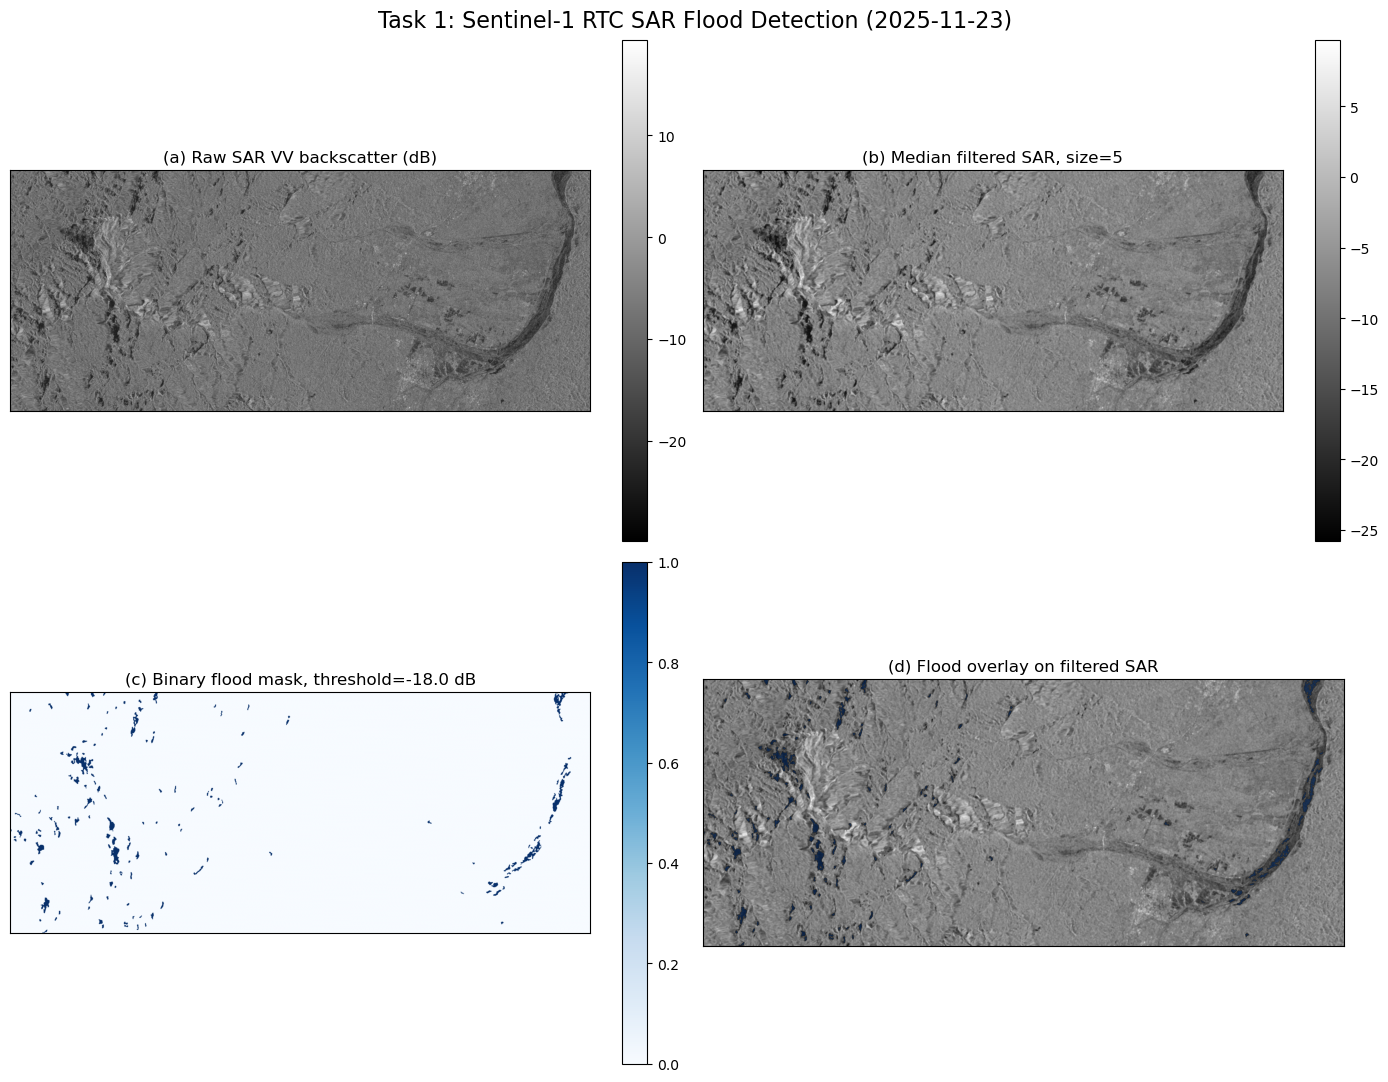

Saved: outputs_week10\task1_sar_histogram_threshold.png


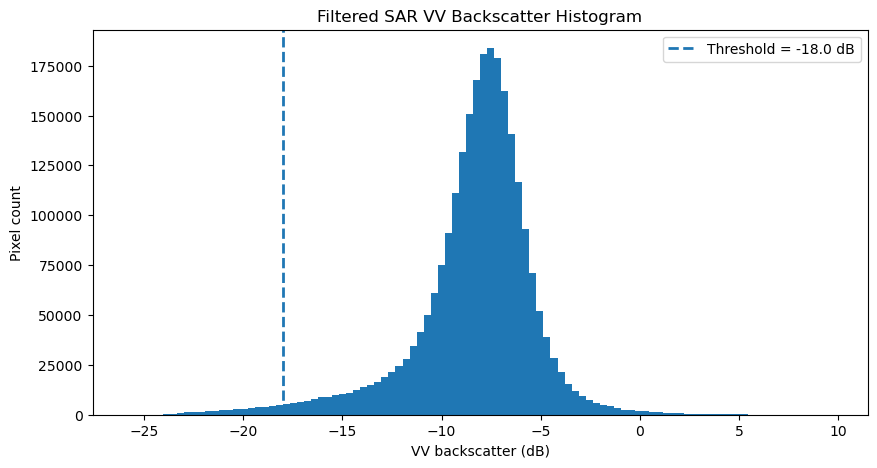

In [10]:
# Required Task 1 visualizations.
plot_sar_task(
    raw_db=post_vv_db_raw,
    filtered_db=post_vv_db_filtered,
    flood_mask=sar_flood_mask,
    threshold=SAR_THRESHOLD,
    title_prefix=f"Task 1: Sentinel-1 RTC SAR Flood Detection ({item_datetime(post_s1_item).date()})",
)

plot_histogram(post_vv_db_filtered, SAR_THRESHOLD)

In [11]:
task1_statement = (
    f"SAR detected {sar_area_km2:.3f} km² of flooding that optical sensors may not see "
    f"under cloud cover. The flood mask contains {sar_water_pixels:,} water pixels, "
    f"with mean VV backscatter of {sar_mean_backscatter:.2f} dB in detected flood zones."
)
print(task1_statement)

SAR detected 3.285 km² of flooding that optical sensors may not see under cloud cover. The flood mask contains 32,854 water pixels, with mean VV backscatter of -20.30 dB in detected flood zones.


### Task 1 Interpretation

Captain's Log: 判釋時要檢查 flood mask 是否出現在合理地形位置，尤其不能大量出現在山頂或整個研究區。如果淹水區過大，通常代表 SAR threshold 太寬鬆、未先做 median filter、或需要更強的 connected component filtering。

## Task 2 — Sensor Fusion: Multi-Source Confidence Map

Captain's Log: 光學影像在颱風期間可能被雲遮住，所以本段不是用 Sentinel-2 取代 SAR，而是把 NDWI 當成補充證據。雙重證據區為 High Confidence；只有 SAR 但雲遮區則保留為 SAR Only，代表雷達補上了光學看不到的地方。

In [12]:
# Search Sentinel-2 L2A items during the post-event period.
s2_post_items = search_items(S2_COLLECTION, HUALIEN_BBOX, POST_DATE_RANGE, max_items=100)
s2_post_table = summarize_items(s2_post_items, sensor="S2")

print("Post-event Sentinel-2 L2A items:")
display(s2_post_table)

if len(s2_post_items) == 0:
    selected_s2_item = None
    print("No Sentinel-2 items found. The notebook will create a 100% cloud mask.")
else:
    selected_s2_item = min(s2_post_items, key=lambda item: item.properties.get("eo:cloud_cover", 999))
    print(
        "Selected Sentinel-2 item:",
        selected_s2_item.id,
        "| datetime:",
        item_datetime(selected_s2_item),
        "| cloud cover:",
        selected_s2_item.properties.get("eo:cloud_cover", np.nan),
    )

Post-event Sentinel-2 L2A items:


,idx,id,datetime,collection,cloud_cover,platform
0,4,S2B_MSIL2A_20251115T022849_R046_T51QUG_2025111...,2025-11-15 02:28:49.024000+00:00,sentinel-2-l2a,46.245357,Sentinel-2B
1,3,S2C_MSIL2A_20251120T024011_R046_T51QUG_2025112...,2025-11-20 02:40:11.025000+00:00,sentinel-2-l2a,75.384218,Sentinel-2C
2,2,S2A_MSIL2A_20251122T023141_R046_T51QUG_2025112...,2025-11-22 02:31:41.024000+00:00,sentinel-2-l2a,46.219483,Sentinel-2A
3,1,S2B_MSIL2A_20251125T022929_R046_T51QUG_2025112...,2025-11-25 02:29:29.024000+00:00,sentinel-2-l2a,78.179252,Sentinel-2B
4,0,S2C_MSIL2A_20251130T023051_R046_T51QUG_2025113...,2025-11-30 02:30:51.025000+00:00,sentinel-2-l2a,44.908321,Sentinel-2C


Selected Sentinel-2 item: S2C_MSIL2A_20251130T023051_R046_T51QUG_20251130T052811 | datetime: 2025-11-30 02:30:51.025000+00:00 | cloud cover: 44.908321


In [13]:
def load_s2_ndwi_cloud(item, bbox, epsg=32651, resolution=10, target_shape=None):
    """Load Sentinel-2 Green, NIR, and SCL to compute NDWI and cloud mask."""
    if item is None:
        if target_shape is None:
            raise ValueError("target_shape is required when no Sentinel-2 item exists.")
        ndwi = np.full(target_shape, np.nan, dtype=np.float32)
        clear_mask = np.zeros(target_shape, dtype=bool)
        cloud_mask = np.ones(target_shape, dtype=bool)
        return ndwi, clear_mask, cloud_mask

    signed_item = pc.sign(item)
    cube = stackstac.stack(
        [signed_item],
        assets=["B03", "B08", "SCL"],
        epsg=epsg,
        resolution=resolution,
        bounds_latlon=bbox,
        rescale=False,
        chunksize=2048,
    )
    cube = safe_compute(cube)

    green = dataarray_to_2d(cube.sel(band="B03")).values.astype(np.float32)
    nir = dataarray_to_2d(cube.sel(band="B08")).values.astype(np.float32)
    scl = dataarray_to_2d(cube.sel(band="SCL")).values.astype(np.float32)

    ndwi = (green - nir) / (green + nir + 1e-6)

    clear_mask = np.isin(scl.astype(np.int16), CLEAR_SCL_CLASSES)
    cloud_mask = ~clear_mask | ~np.isfinite(ndwi)

    if target_shape is not None:
        ndwi = align_to_shape(ndwi, target_shape, order=1, fill_value=np.nan)
        clear_mask = align_to_shape(clear_mask.astype(float), target_shape, order=0, fill_value=0).astype(bool)
        cloud_mask = align_to_shape(cloud_mask.astype(float), target_shape, order=0, fill_value=1).astype(bool)

    return ndwi, clear_mask, cloud_mask

ndwi, clear_mask, cloud_mask = load_s2_ndwi_cloud(
    selected_s2_item,
    HUALIEN_BBOX,
    TARGET_EPSG,
    resolution=PIXEL_SIZE_M,
    target_shape=sar_flood_mask.shape,
)

optical_water_mask = (ndwi > NDWI_THRESHOLD) & clear_mask

assert sar_flood_mask.shape == optical_water_mask.shape == cloud_mask.shape

cloud_cover_percent = float(np.mean(cloud_mask) * 100)
optical_water_area_km2 = area_from_mask(optical_water_mask)

print(f"NDWI threshold: {NDWI_THRESHOLD}")
print(f"Estimated cloud-masked percentage in AOI: {cloud_cover_percent:.2f}%")
print(f"Optical water area from clear pixels: {optical_water_area_km2:.3f} km²")
print_sanity_check(optical_water_mask, "Optical NDWI water mask")

NDWI threshold: 0.0
Estimated cloud-masked percentage in AOI: 7.46%
Optical water area from clear pixels: 20.524 km²
Optical NDWI water mask: detected fraction = 8.10%
✅ Detection fraction is within a plausible first-pass range.


,class,classification,pixels,area_km2,percent_of_aoi
0,0,No Detection,2306936,230.6936,91.031402
1,1,Optical Only,194430,19.4430,7.672183
2,2,SAR Only / Cloudy or Review,22039,2.2039,0.869656
3,3,High Confidence,10815,1.0815,0.426759


Saved: outputs_week10\task2_fusion_confidence_map.png


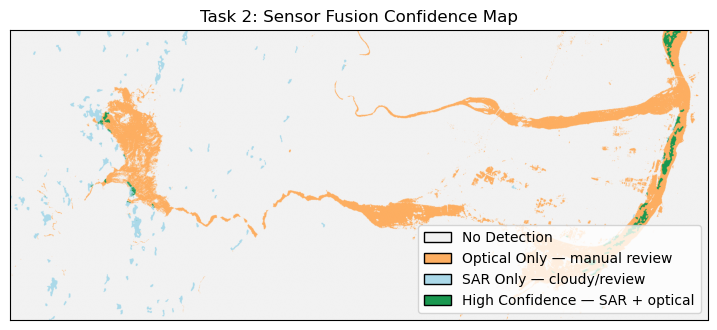

In [14]:
def build_fusion_map(optical_mask, sar_mask, cloud_mask):
    """Build 4-class fusion confidence map from optical, SAR, and cloud masks."""
    fusion = np.zeros(sar_mask.shape, dtype=np.uint8)

    # Optical-only: visible optical evidence but no SAR confirmation.
    fusion[(optical_mask) & (~sar_mask) & (~cloud_mask)] = 1

    # SAR-only: includes cloudy SAR detections and non-cloud SAR-only detections requiring review.
    fusion[(sar_mask) & (~optical_mask)] = 2

    # High confidence: both SAR and optical agree in non-cloud pixels.
    fusion[(optical_mask) & (sar_mask) & (~cloud_mask)] = 3

    return fusion

fusion_map = build_fusion_map(optical_water_mask, sar_flood_mask, cloud_mask)
fusion_stats = class_area_table(fusion_map)

display(fusion_stats)
plot_fusion_map(
    fusion_map,
    "Task 2: Sensor Fusion Confidence Map",
    "task2_fusion_confidence_map.png",
)

In [15]:
high_conf_area_km2 = float(fusion_stats.loc[fusion_stats["class"] == 3, "area_km2"].iloc[0])
sar_only_area_km2 = float(fusion_stats.loc[fusion_stats["class"] == 2, "area_km2"].iloc[0])
optical_only_area_km2 = float(fusion_stats.loc[fusion_stats["class"] == 1, "area_km2"].iloc[0])
no_detection_area_km2 = float(fusion_stats.loc[fusion_stats["class"] == 0, "area_km2"].iloc[0])

task2_interpretation = (
    f"High confidence zones cover {high_conf_area_km2:.3f} km². "
    f"SAR-only zones add {sar_only_area_km2:.3f} km² of flood detection in cloudy or optical-uncertain areas. "
    f"Optical-only zones cover {optical_only_area_km2:.3f} km² and should be manually reviewed."
)
print(task2_interpretation)

High confidence zones cover 1.082 km². SAR-only zones add 2.204 km² of flood detection in cloudy or optical-uncertain areas. Optical-only zones cover 19.443 km² and should be manually reviewed.


### Task 2 Interpretation

Captain's Log: High Confidence 代表 SAR 與 NDWI 同時支持水體判釋，因此最適合作為優先應變依據。SAR Only 區域雖然可能包含雲遮下的真實淹水，但也可能有地形、陰影或低回波表面的誤判，因此需要在 Task 3 加入 DEM 地形審計。

## Task 3 — Topographic Analysis: DEM & Slope Assessment

Captain's Log: SAR 在陡峭地形會受到 layover、foreshortening 等幾何效應影響，導致山坡上出現類似水體的低回波。因此本段使用 Copernicus DEM 計算 slope，將坡度大於 25° 的 flood detections 標記為可能 false positive。

In [16]:
def load_cop_dem(bbox, epsg=32651, resolution=30):
    """Load Copernicus DEM from Planetary Computer and return a 2-D elevation array."""
    dem_items = search_items(DEM_COLLECTION, bbox, datetime_range=None, max_items=50)
    if len(dem_items) == 0:
        raise ValueError("No Copernicus DEM items found for this BBOX.")

    cube = stackstac.stack(
        [pc.sign(item) for item in dem_items],
        assets=["data"],
        epsg=epsg,
        resolution=resolution,
        bounds_latlon=bbox,
        chunksize=2048,
    )

    # For adjacent DEM tiles, take the median mosaic along time dimension.
    dem_da = cube.squeeze(drop=True)
    if "time" in dem_da.dims:
        dem_da = dem_da.median(dim="time", skipna=True)
    if "band" in dem_da.dims:
        dem_da = dem_da.isel(band=0)

    dem = safe_compute(dem_da).values.astype(np.float32)
    dem = np.where(np.isfinite(dem), dem, np.nan)
    return dem

def compute_slope_degrees(dem, pixel_size_m=30):
    """Compute slope in degrees from a DEM using finite differences."""
    dem = np.asarray(dem, dtype=np.float32)
    dem_filled = dem.copy()
    if np.isnan(dem_filled).any():
        median_val = np.nanmedian(dem_filled)
        dem_filled = np.where(np.isfinite(dem_filled), dem_filled, median_val)

    dy, dx = np.gradient(dem_filled, pixel_size_m, pixel_size_m)
    slope = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))
    slope = np.where(np.isfinite(dem), slope, np.nan)
    return slope

dem = load_cop_dem(HUALIEN_BBOX, TARGET_EPSG, resolution=30)
slope_deg_30m = compute_slope_degrees(dem, pixel_size_m=30)

# Align slope to SAR/fusion grid.
slope_deg = align_to_shape(slope_deg_30m, fusion_map.shape, order=1, fill_value=np.nan)

print("DEM shape:", dem.shape)
print("Slope aligned shape:", slope_deg.shape)
print("Slope percentiles:", np.nanpercentile(slope_deg, [5, 25, 50, 75, 95]))

DEM shape: (343, 824)
Slope aligned shape: (1026, 2470)
Slope percentiles: [ 0.63366408  2.86234057 24.47961998 33.68240166 46.66410332]


In [17]:
# Apply topographic filter: slope > threshold cannot reasonably hold standing flood water.
steep_mask = slope_deg > SLOPE_THRESHOLD
removed_by_topography = (fusion_map > 0) & steep_mask

fusion_topo_corrected = fusion_map.copy()
fusion_topo_corrected[removed_by_topography] = 0

false_positive_removed_km2 = area_from_mask(removed_by_topography)

fusion_topo_stats = class_area_table(fusion_topo_corrected)

print(f"False positives removed by slope > {SLOPE_THRESHOLD}°: {false_positive_removed_km2:.3f} km²")
display(fusion_topo_stats)

False positives removed by slope > 25.0°: 6.307 km²


,class,classification,pixels,area_km2,percent_of_aoi
0,0,No Detection,2370003,237.0003,93.520018
1,1,Optical Only,153044,15.3044,6.039097
2,2,SAR Only / Cloudy or Review,1626,0.1626,0.064162
3,3,High Confidence,9547,0.9547,0.376723


In [18]:
def slope_removal_table(removed_mask, slope):
    """Summarize topographic removals by slope class."""
    bins = [
        ("25–35°", (slope > 25) & (slope <= 35)),
        ("35–45°", (slope > 35) & (slope <= 45)),
        (">45°", slope > 45),
    ]
    rows = []
    for label, bin_mask in bins:
        mask = removed_mask & bin_mask
        pixels = int(np.sum(mask))
        rows.append({
            "slope_class": label,
            "removed_pixels": pixels,
            "removed_area_km2": pixels * PIXEL_AREA_KM2,
        })
    return pd.DataFrame(rows)

removed_slope_table = slope_removal_table(removed_by_topography, slope_deg)
display(removed_slope_table)

,slope_class,removed_pixels,removed_area_km2
0,25–35°,22771,2.2771
1,35–45°,19719,1.9719
2,>45°,20577,2.0577


Saved: outputs_week10\task3_before_topographic_correction.png


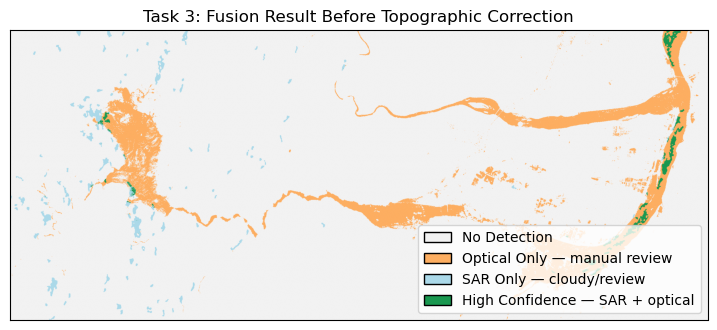

Saved: outputs_week10\task3_after_topographic_correction.png


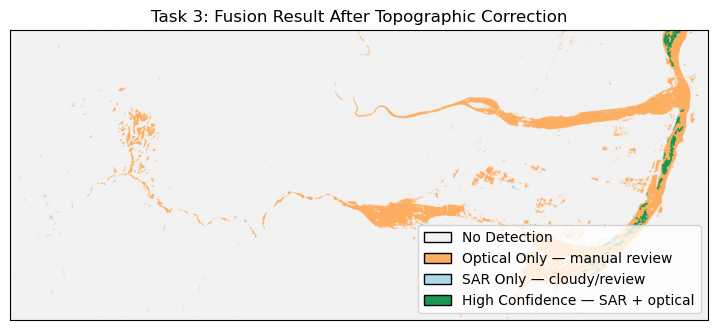

Saved: outputs_week10\task3_dem_slope_maps.png


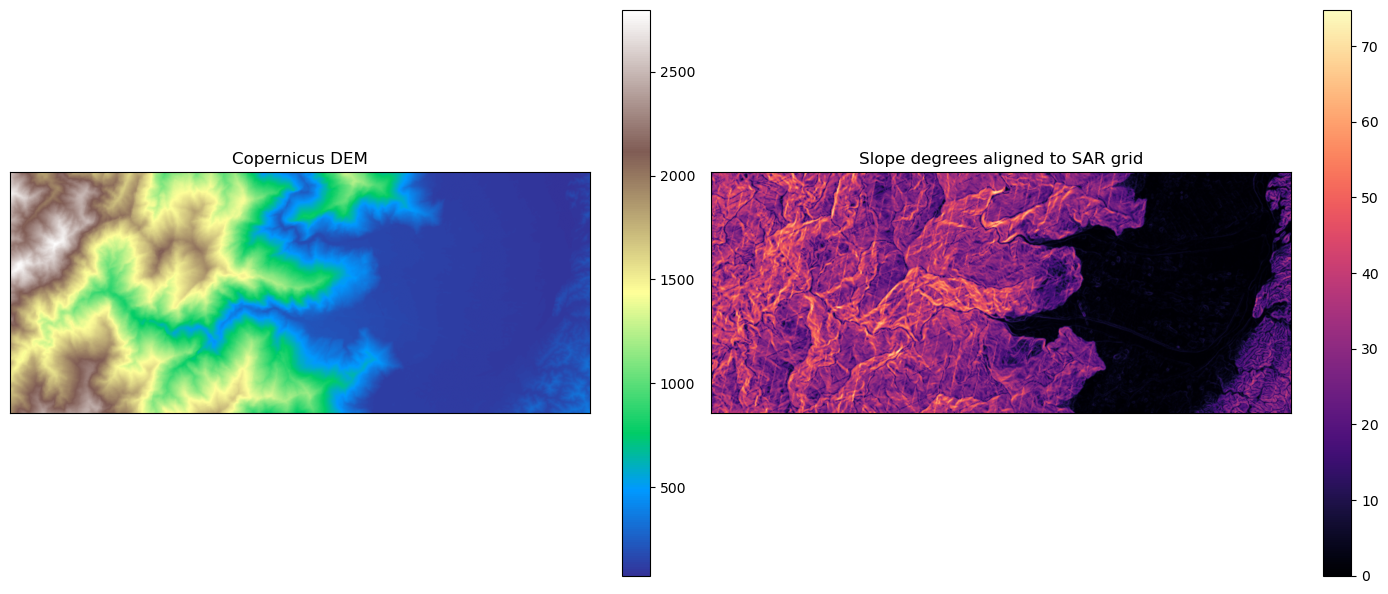

In [19]:
# Required before/after maps.
plot_fusion_map(
    fusion_map,
    "Task 3: Fusion Result Before Topographic Correction",
    "task3_before_topographic_correction.png",
)

plot_fusion_map(
    fusion_topo_corrected,
    "Task 3: Fusion Result After Topographic Correction",
    "task3_after_topographic_correction.png",
)

# DEM and slope quick visual check.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
im0 = axes[0].imshow(dem, cmap="terrain")
axes[0].set_title("Copernicus DEM")
axes[0].set_xticks([])
axes[0].set_yticks([])
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(slope_deg, cmap="magma")
axes[1].set_title("Slope degrees aligned to SAR grid")
axes[1].set_xticks([])
axes[1].set_yticks([])
plt.colorbar(im1, ax=axes[1], fraction=0.046)

fig.tight_layout()
out = OUTPUT_DIR / "task3_dem_slope_maps.png"
fig.savefig(out, dpi=180, bbox_inches="tight")
print(f"Saved: {out}")
plt.show()

### DEM 適用性分析

在本案例中，Copernicus DEM 適合用於**花蓮平原與下游沖積扇**的保守地形校正，因為這些區域的地形相對穩定，坡度大於 25° 的像元通常不應該被判定為積水。不過，在馬太鞍溪上游崩塌區，颱風與崩塌可能已經改變實際地形，舊 DEM 未必能反映災後坡度，因此不能把 DEM 視為絕對真值。若 DEM 不適用，我會優先使用 morphological opening、connected component filtering、河道位置比對與人工檢核來清除假水體。

## Task 4A — AI Strategic Briefing

Captain's Log: 這裡將 Task 1–3 的量化結果整理成 emergency management prompt。請執行下方 cell，複製產生的 exact prompt 到 ChatGPT / Gemini / Claude，並將回覆貼回 `LLM_RESPONSE` 變數中。

In [20]:
# Build metrics for AI strategic briefing.
metrics = {
    "high_conf_area_km2": high_conf_area_km2,
    "sar_only_area_km2": sar_only_area_km2,
    "optical_only_area_km2": optical_only_area_km2,
    "false_positive_removed_km2": false_positive_removed_km2,
    "cloud_cover_percent": cloud_cover_percent,
    "sar_threshold": SAR_THRESHOLD,
    "ndwi_threshold": NDWI_THRESHOLD,
    "slope_threshold": SLOPE_THRESHOLD,
    "sar_area_km2": sar_area_km2,
}

llm_prompt = f"""
You are an emergency management advisor for Hualien County after Typhoon Fung-wong (November 2025). 
The Matai'an Creek barrier lake has overflowed, flooding Wanrong, Guangfu, and Fenglin townships.

Based on these ARIA v7.0 sensor fusion results, generate a strategic briefing that covers:
1. Which areas require immediate evacuation?
2. How should resources be allocated between high-confidence and SAR-only zones?
3. What are the limitations of the current assessment?
4. What additional data would improve confidence?

Key metrics:
- High confidence flood area: {metrics['high_conf_area_km2']:.3f} km²
- SAR-only cloudy/review flood area: {metrics['sar_only_area_km2']:.3f} km²
- Optical-only manual review area: {metrics['optical_only_area_km2']:.3f} km²
- False positives removed by topographic filter: {metrics['false_positive_removed_km2']:.3f} km²
- Cloud cover percentage: {metrics['cloud_cover_percent']:.2f}%
- SAR threshold: {metrics['sar_threshold']} dB. I chose this value because low VV backscatter indicates smooth water surfaces, and the histogram was used to position the cutoff before morphological cleanup.
- NDWI threshold: {metrics['ndwi_threshold']}. I chose this value because floodwater in typhoon events is often turbid, so a lower NDWI threshold can be more appropriate than the clear-water default.
- Slope threshold: {metrics['slope_threshold']}°. Pixels steeper than this were treated as topographic false positives.
""".strip()

print(llm_prompt)

You are an emergency management advisor for Hualien County after Typhoon Fung-wong (November 2025). 
The Matai'an Creek barrier lake has overflowed, flooding Wanrong, Guangfu, and Fenglin townships.

Based on these ARIA v7.0 sensor fusion results, generate a strategic briefing that covers:
1. Which areas require immediate evacuation?
2. How should resources be allocated between high-confidence and SAR-only zones?
3. What are the limitations of the current assessment?
4. What additional data would improve confidence?

Key metrics:
- High confidence flood area: 1.082 km²
- SAR-only cloudy/review flood area: 2.204 km²
- Optical-only manual review area: 19.443 km²
- False positives removed by topographic filter: 6.307 km²
- Cloud cover percentage: 7.46%
- SAR threshold: -18.0 dB. I chose this value because low VV backscatter indicates smooth water surfaces, and the histogram was used to position the cutoff before morphological cleanup.
- NDWI threshold: 0.0. I chose this value because floo

### LLM Response

Based on the ARIA v7.0 sensor fusion results, Hualien County should treat the mapped flood extent as an operational warning layer rather than a final damage inventory. The highest priority for immediate evacuation should be the **high-confidence flood zones** covering approximately **1.082 km²**, especially low-lying settlements, roads, bridges, and river-adjacent areas in Wanrong, Guangfu, and Fenglin townships. These areas have both SAR and optical evidence of flooding, so they represent the strongest evidence of actual inundation. Evacuation orders should first target residents located within or directly adjacent to these high-confidence zones, particularly along the Matai'an Creek downstream corridor and floodplain.

The **SAR-only cloudy/review zones**, covering approximately **2.204 km²**, should be treated as a second-priority but still urgent operational zone. Because SAR can detect smooth water surfaces through cloud cover, these areas may represent real flooding that optical sensors could not confirm. Emergency teams should not dismiss these areas simply because optical confirmation is lacking. Instead, they should receive rapid field verification, drone reconnaissance, or reports from local officials. If these zones overlap with populated areas, critical infrastructure, evacuation routes, or river channels, precautionary evacuation or access restriction should be considered until field confirmation is available.

Resource allocation should follow a tiered strategy. First, rescue, evacuation, and road-closure resources should be concentrated in the **high-confidence zones** because these areas have the strongest multi-sensor evidence. Second, mobile reconnaissance teams should be assigned to the **SAR-only zones** to verify whether flooding is present beneath cloud cover. Third, the **optical-only manual review area**, which is much larger at **19.443 km²**, should be reviewed carefully before major operational decisions are made, because optical-only detections may include turbid water, wet sediment, debris, shadow, or spectral confusion. These areas are important for monitoring and planning, but they should not automatically receive the same response priority as dual-evidence flood zones.

The current assessment has several limitations. First, although the cloud cover percentage is relatively low at **7.46%**, cloud and shadow effects can still affect optical NDWI results. Second, SAR flood detection can produce false positives in steep terrain, radar shadow, layover, or very smooth non-water surfaces. The removal of **6.307 km²** of false positives using the 25° slope threshold shows that topographic correction was important, but it also suggests that the original SAR mask contained substantial terrain-related noise. Third, the SAR threshold of **-18.0 dB** and NDWI threshold of **0.0** are reasonable for turbid typhoon floodwater, but both are still threshold-based decisions and may vary by land cover, water roughness, vegetation, and sediment concentration. Fourth, the DEM used for slope filtering may not fully represent post-disaster terrain, especially in areas affected by landslides, debris flow, or barrier-lake erosion.

Additional data would improve confidence in several ways. Field reports from village offices, police, fire departments, and local residents would help validate whether mapped flood zones correspond to real inundation. Drone imagery or aerial photographs would be especially valuable for checking SAR-only and optical-only review areas. Higher-resolution satellite imagery after cloud clearance would improve manual interpretation. Updated DEM or LiDAR data would help assess whether topographic correction remains valid after landslides or debris deposition. Finally, river gauge data, rainfall records, road closure reports, and geotagged disaster photos could be integrated with the ARIA v7.0 map to produce a more reliable operational flood assessment.

Overall, the ARIA v7.0 result supports an emergency strategy of **immediate action in high-confidence flood zones**, **rapid verification and precautionary management in SAR-only zones**, and **manual review for optical-only detections**. The fused SAR–optical approach improves disaster response because it provides flood evidence even when optical imagery is limited by clouds, while the topographic audit reduces unrealistic detections on steep slopes.

### My Reflection

The LLM correctly prioritizes high-confidence zones for immediate evacuation because those areas are supported by both SAR and optical evidence. It also appropriately treats SAR-only zones as urgent review areas rather than ignoring them, which matches the purpose of ARIA v7.0 as an all-weather auditor. However, the response remains general because the input metrics do not include exact village boundaries, road names, or population exposure data. Therefore, I would use this briefing as a strategic decision-support summary, but final evacuation decisions should still be combined with field reports, drone imagery, and local government information.

## Task 4B — ARIA v7.0 vs. v6.0 Comparison

Captain's Log: W9 optical-only 方法在晴空條件下有效，但在颱風雲遮期間會失去地面資訊。W10 的進步在於加入 Sentinel-1 SAR，使系統即使在雲層下也能提供 flood detection；但同時也必須面對 SAR speckle 與地形誤判。

In [22]:
# W9 values extracted from Week9_ARIA_v60_Notebook_Structure.ipynb.
# W9 High Confidence = 15.0307 km²
# W9 Low Confidence  = 9.7008 km²
# Therefore, W9 total detected optical-only impact area = High + Low.
W9_TOTAL_DETECTED_FLOOD_AREA_KM2 = 24.7315

# W9 is optical-only, so cloud-covered ground cannot be analyzed directly.
W9_CLOUD_COVERED_AREA_ANALYZED_KM2 = 0.0

# From W9 phantom-water comparison:
# phantom_water fraction = 0.09820258193009349 over a 2243 × 2474 grid at 10 m resolution
# area = 0.09820258193009349 × 2243 × 2474 × 0.0001 km² = 54.4944 km².
# This represents raw optical false-positive artifacts before SCL cloud masking.
W9_FALSE_POSITIVES_PRE_CORRECTION = 54.4944

W9_CONFIDENCE_LEVELS = "3-zone"

# W10 values from this notebook.
W10_TOTAL_DETECTED_FLOOD_AREA_KM2 = high_conf_area_km2 + sar_only_area_km2 + optical_only_area_km2
W10_CLOUD_COVERED_AREA_ANALYZED_KM2 = sar_only_area_km2
W10_FALSE_POSITIVES_PRE_CORRECTION = false_positive_removed_km2
W10_CONFIDENCE_LEVELS = "4-class"

comparison_table = pd.DataFrame([
    {
        "Metric": "Total detected flood area",
        "W9 (Optical Only)": f"{W9_TOTAL_DETECTED_FLOOD_AREA_KM2:.3f} km²",
        "W10 (Fused)": f"{W10_TOTAL_DETECTED_FLOOD_AREA_KM2:.3f} km²",
        "Improvement": f"+{W10_TOTAL_DETECTED_FLOOD_AREA_KM2 - W9_TOTAL_DETECTED_FLOOD_AREA_KM2:.3f} km²",
    },
    {
        "Metric": "Cloud-covered area analyzed",
        "W9 (Optical Only)": f"{W9_CLOUD_COVERED_AREA_ANALYZED_KM2:.3f} km²",
        "W10 (Fused)": f"{W10_CLOUD_COVERED_AREA_ANALYZED_KM2:.3f} km²",
        "Improvement": "SAR provides all-weather coverage",
    },
    {
        "Metric": "False positives removed by topographic / quality audit",
        "W9 (Optical Only)": f"{W9_FALSE_POSITIVES_PRE_CORRECTION:.3f} km² phantom-water artifacts before SCL masking",
        "W10 (Fused)": f"{W10_FALSE_POSITIVES_PRE_CORRECTION:.3f} km² steep-slope SAR detections removed",
        "Improvement": "Quality audit reduces sensor-specific false positives",
    },
    {
        "Metric": "Confidence levels",
        "W9 (Optical Only)": W9_CONFIDENCE_LEVELS,
        "W10 (Fused)": W10_CONFIDENCE_LEVELS,
        "Improvement": "Finer granularity",
    },
])

display(comparison_table)



,Metric,W9 (Optical Only),W10 (Fused),Improvement
0,Total detected flood area,24.732 km²,22.728 km²,+-2.003 km²
1,Cloud-covered area analyzed,0.000 km²,2.204 km²,SAR provides all-weather coverage
2,False positives removed by topographic / quali...,54.494 km² phantom-water artifacts before SCL ...,6.307 km² steep-slope SAR detections removed,Quality audit reduces sensor-specific false po...
3,Confidence levels,3-zone,4-class,Finer granularity


In [23]:
comparison_interpretation = f"""
## ARIA v7.0 vs. v6.0 Comparison

Compared with W9 optical-only detection, ARIA v7.0 improves operational reliability by adding Sentinel-1 SAR, which can observe the surface under cloud cover. 
In this run, the fused map detected {W10_TOTAL_DETECTED_FLOOD_AREA_KM2:.3f} km² of potential flood-related area, including {sar_only_area_km2:.3f} km² from SAR-only cloudy/review zones. 
The topographic audit removed {false_positive_removed_km2:.3f} km² of detections on slopes steeper than {SLOPE_THRESHOLD}°, reducing likely SAR terrain false positives. 
The main improvement is not only more detected area, but also better uncertainty communication through four classes: high confidence, SAR-only, optical-only, and no detection.
""".strip()

print(comparison_interpretation)

## ARIA v7.0 vs. v6.0 Comparison

Compared with W9 optical-only detection, ARIA v7.0 improves operational reliability by adding Sentinel-1 SAR, which can observe the surface under cloud cover. 
In this run, the fused map detected 22.728 km² of potential flood-related area, including 2.204 km² from SAR-only cloudy/review zones. 
The topographic audit removed 6.307 km² of detections on slopes steeper than 25.0°, reducing likely SAR terrain false positives. 
The main improvement is not only more detected area, but also better uncertainty communication through four classes: high confidence, SAR-only, optical-only, and no detection.


## Output Verification Checklist

Captain's Log: 送出前請逐項檢查，避免把未驗證的圖與數字交出去。

- [ ] SAR pre/post scenes use the same orbit direction.
- [ ] Median filter was applied before SAR thresholding.
- [ ] SAR histogram supports the selected threshold.
- [ ] Flood mask does not cover the entire AOI or mountaintops.
- [ ] SAR and optical masks have the same shape.
- [ ] Fusion map has four confidence classes.
- [ ] DEM slope filter was discussed critically, not treated as perfect truth.
- [ ] AI prompt and response are documented.
- [ ] W9 comparison values are filled from the previous notebook.

In [24]:
# Save summary tables for submission appendix.
task1_stats.to_csv(OUTPUT_DIR / "task1_sar_stats.csv", index=False)
fusion_stats.to_csv(OUTPUT_DIR / "task2_fusion_area_stats.csv", index=False)
fusion_topo_stats.to_csv(OUTPUT_DIR / "task3_fusion_topo_corrected_stats.csv", index=False)
removed_slope_table.to_csv(OUTPUT_DIR / "task3_slope_false_positive_removed.csv", index=False)
comparison_table.to_csv(OUTPUT_DIR / "task4_w9_w10_comparison.csv", index=False)

print(f"All tables saved to: {OUTPUT_DIR.resolve()}")

All tables saved to: D:\Class_satellite\HW10\outputs_week10


## Final Submission Notes

Notebook filename suggestion: `Week10_ARIA_v70_PoWeiHuang.ipynb`

請同時附上：

1. This notebook  
2. `.env` file  
3. `outputs_week10/` figures and CSV tables  
4. AI strategic briefing exact prompt and exact response  
5. W9 vs W10 comparison table with W9 real values filled in  

Captain's final thought: A commander does not care if it is cloudy. ARIA v7.0 delivers the best available evidence, while clearly separating high-confidence results from zones requiring review.